# Rollout Analysis
Plot actual vs target joint positions per joint from a `ur_rtde_real_time.py` NPZ log.

In [ ]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

joint_names = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]

# Trajectory dt — both real-robot (ur_rtde_real_time.py at 500 Hz) and sim (record.py at
# 50 Hz) rollouts share the same underlying policy/trajectory rate of 50 Hz, so this is
# the constant we use to derive decimation = round(POLICY_DT / src_dt).
POLICY_DT = 0.02


def _src_dt(d):
    """Sample period of the rollout. Both record.py and the new ur_rtde_real_time.py
    write `src_dt`. Older real-rollout npz files don't, so fall back to 500 Hz."""
    return float(d["src_dt"]) if "src_dt" in d.files else (1.0 / 500.0)


def _decimation(d):
    """Control steps per policy step. 10 for real (500 Hz / 50 Hz), 1 for sim."""
    return max(1, int(round(POLICY_DT / _src_dt(d))))


def _rate_hz(d):
    """Sample rate of the rollout in Hz, for axis labels."""
    return 1.0 / _src_dt(d)


def analyze(npz_path, ds=5):
    """Plot joint trajectories, then box estimate vs ground-truth box pose from the trajectory."""
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    actual = d["actual_q"]
    expected = d["expected_q"]
    target = d["target_q"]
    steps = d["steps"]
    title = npz_path.stem
    decimation = _decimation(d)
    rate_hz = _rate_hz(d)

    # Load planner's joint targets from the trajectory file (path stored in env.yaml)
    run_dir = npz_path.parent.parent
    env_yaml = run_dir / "params" / "env.yaml"
    with open(env_yaml, "r") as f:
        env_cfg = yaml.unsafe_load(f)
    traj_path = env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path  # relative to repo root
    traj = np.load(traj_path)
    joints_target_full = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints_full = traj["joints"] if "joints" in traj.files else traj["joints_l"]
    obj_poses_full = traj["obj_poses"]  # (T, 7): pos[:3], quat[3:]

    # Mirror the control thread's interpolation: starts from the planned initial joint
    # position (joints[0]), then transitions to joints_target[0] over the first
    # `decimation` steps, and so on. Prepending joints[0] makes step (i+1)*decimation
    # land exactly on trajectory waypoint i.
    ref_points = np.vstack([joints_full[0:1], joints_target_full])  # (T+1, 6)
    traj_x = np.arange(len(ref_points)) * decimation  # 0, decimation, 2*decimation, ...
    # Generate ref_target across the full trajectory (independent of rollout step count)
    ref_steps = np.arange(traj_x[-1] + 1)
    ref_target = np.empty((len(ref_steps), ref_points.shape[1]))
    for j in range(ref_points.shape[1]):
        ref_target[:, j] = np.interp(ref_steps, traj_x, ref_points[:, j])

    print(f"{title}: {len(steps)} rollout steps, {len(ref_steps)} ref steps, "
          f"rate={rate_hz:.0f}Hz, decimation={decimation}, "
          f"gain={float(d['gain'])}, lookahead={float(d['lookahead_time'])}, "
          f"action_scale={float(d['action_scale'])}")

    xlabel = f"step ({rate_hz:.0f}Hz)"

    # Position plot
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(steps[::ds], expected[::ds, i], label='reference q', color='gray', linestyle='--', alpha=0.7)
        ax.plot(ref_steps[::ds], ref_target[::ds, i], label='reference target', color='tab:green', linestyle=':', alpha=0.8)
        ax.plot(steps[::ds], target[::ds, i], label='policy target', color='tab:orange', alpha=0.8)
        ax.plot(steps[::ds], actual[::ds, i], label='actual', color='tab:blue', alpha=0.8)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()

    # Box estimate vs ground truth — only if the rollout logged box pose + phase.
    if "actual_obj_pos" not in d.files or "actual_obj_quat" not in d.files or "phase" not in d.files:
        print("(box pose / phase missing from npz; skipping box-pose plot)")
        return

    actual_obj_pos = d["actual_obj_pos"]    # (N, 3) — NaN where no pose was available
    actual_obj_quat = d["actual_obj_quat"]  # (N, 4) — NaN where no pose was available
    phase = d["phase"]                      # (N,) float trajectory-index units

    # Reference object pose at each rollout step's logged phase. np.interp clamps to the
    # endpoints, so phases outside [0, T-1] just stick to the closest end.
    T_obj = obj_poses_full.shape[0]
    obj_idx = np.arange(T_obj)
    ref_obj_pos = np.column_stack([
        np.interp(phase, obj_idx, obj_poses_full[:, j]) for j in range(3)
    ])
    ref_obj_quat = np.column_stack([
        np.interp(phase, obj_idx, obj_poses_full[:, 3 + j]) for j in range(4)
    ])

    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    pos_slots = [(0, 0), (0, 1), (1, 0)]
    pos_labels = ["pos x", "pos y", "pos z"]
    for i, ((r, c), label) in enumerate(zip(pos_slots, pos_labels)):
        ax = axes[r, c]
        ax.plot(steps[::ds], ref_obj_pos[::ds, i], label='ground truth (trajectory)',
                color='tab:green', linestyle='--', alpha=0.85)
        ax.plot(steps[::ds], actual_obj_pos[::ds, i], label='estimate (pose listener)',
                color='tab:blue', alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('m')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[1, 1].axis('off')

    quat_slots = [(2, 0), (2, 1), (3, 0), (3, 1)]
    quat_labels = ["quat[0]", "quat[1]", "quat[2]", "quat[3]"]
    for i, ((r, c), label) in enumerate(zip(quat_slots, quat_labels)):
        ax = axes[r, c]
        ax.plot(steps[::ds], ref_obj_quat[::ds, i], label='ground truth (trajectory)',
                color='tab:green', linestyle='--', alpha=0.85)
        ax.plot(steps[::ds], actual_obj_quat[::ds, i], label='estimate (pose listener)',
                color='tab:blue', alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('quat component')
        ax.grid(True, alpha=0.3)
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Box estimate vs ground truth — {title}", fontsize=11)
    plt.tight_layout()

In [62]:
def compare_rollouts(npz_path_a, npz_path_b, ds=1, plot_target=True, plot_expected=True):
    """Overlay target and actual joint positions from two rollouts per joint."""
    npz_path_a = Path(npz_path_a)
    npz_path_b = Path(npz_path_b)
    a = np.load(npz_path_a)
    b = np.load(npz_path_b)

    print(a.keys())
    label_a = npz_path_a.stem
    label_b = npz_path_b.stem

    # Use rollout A's rate for the axis label; if the two rollouts are at different
    # rates the comparison is still meaningful per-step but the label can't reflect both.
    xlabel = f"step ({_rate_hz(a):.0f}Hz)"

    # --- Position overlay ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(a["steps"][::ds], a["actual_q"][::ds, i], color='tab:orange',
                alpha=0.9, label=f'{label_a} actual')
        ax.plot(b["steps"][::ds], b["actual_q"][::ds, i], color='tab:blue',
                alpha=0.9, label=f'{label_b} actual')
        
        if plot_target:
            ax.plot(a["steps"][::ds], a["target_q"][::ds, i], color='tab:orange', linestyle='--',
                alpha=0.7, label=f'{label_a} target')
            ax.plot(b["steps"][::ds], b["target_q"][::ds, i], color='tab:blue', linestyle='--',
                alpha=0.7, label=f'{label_b} target')
            
        if plot_expected:
            ax.plot(a["steps"][::ds], a["expected_q"][::ds, i], color='tab:orange', linestyle='dotted',
                alpha=0.7, label=f'{label_a} target')
            ax.plot(b["steps"][::ds], b["expected_q"][::ds, i], color='tab:blue', linestyle='dotted',
                alpha=0.7, label=f'{label_b} target')
            
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Rollout comparison: {label_a}  vs  {label_b}", fontsize=11)
    plt.tight_layout()

    # --- Tracking error overlay (actual - target) ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(a["steps"][::ds], (a["actual_q"] - a["target_q"])[::ds, i],
                color='tab:orange', alpha=0.85, label=label_a)
        ax.plot(b["steps"][::ds], (b["actual_q"] - b["target_q"])[::ds, i],
                color='tab:blue', alpha=0.85, label=label_b)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('actual - target (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle("Tracking error comparison", fontsize=11)
    plt.tight_layout()

In [63]:
def compare_upsampling_rollout(npz_path, alpha=0.05, policy_decimation=None, ds=5, start_i=0, end_i=None):
    """Given a real rollout's upsampled target_q (produced by linear interpolation at run
    time), extract the underlying 50 Hz policy waypoints and show what the upsampled
    command would have looked like if the control thread had used an IIR low-pass instead.

    Waypoints are recovered by decimating target_q every `policy_decimation` steps. When
    `policy_decimation=None` we read `src_dt` from the npz to derive it (10 for real-robot
    rollouts at 500 Hz, 1 for sim rollouts at 50 Hz). On a sim rollout decimation=1 means
    every step is already a waypoint, so the linear/IIR upsampling is a no-op.
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    target = d["target_q"]  # (N, 6) at the rollout's source rate
    steps = d["steps"]
    rate_hz = _rate_hz(d)

    if policy_decimation is None:
        policy_decimation = _decimation(d)

    # Recover 50 Hz waypoints from the logged ramps.
    wp_idx = np.arange(0, len(target), policy_decimation)
    waypoints = target[wp_idx]  # (T, 6)

    wp_steps = steps[wp_idx]

    if end_i is None:
        end_i = len(target)


    waypoints = waypoints[start_i:end_i]
    wp_steps = wp_steps[start_i:end_i]

    # Re-upsample to the source rate.
    T = len(waypoints)
    segment_steps = policy_decimation
    total_steps = (T - 1) * segment_steps + 1
    dense_x = np.arange(total_steps)
    wp_x = np.arange(T) * segment_steps

    # Linear interpolation (per joint)
    linear = np.empty((total_steps, 6))
    for j in range(6):
        linear[:, j] = np.interp(dense_x, wp_x, waypoints[:, j])

    # First-order IIR low-pass on ZOH-upsampled command
    iir = np.empty_like(linear)
    iir[0] = waypoints[0]
    one_minus_alpha = 1.0 - alpha
    for i, wp in enumerate(waypoints[:-1]):
        for k in range(segment_steps):
            n = i * segment_steps + k
            iir[n + 1] = one_minus_alpha * iir[n] + alpha * wp

    # Align x-axis with the original rollout step indices
    dense_abs_steps = wp_steps[0] + dense_x

    xlabel = f"step ({rate_hz:.0f}Hz)"

    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(wp_steps, waypoints[:, i], 'o', markersize=2.5, color='k',
                alpha=0.5, label='policy waypoints (50 Hz)')
        ax.plot(dense_abs_steps[::ds], linear[::ds, i], label='linear interp (actual)',
                color='tab:green', alpha=0.85)
        ax.plot(dense_abs_steps[::ds], iir[::ds, i], label=f'IIR (α={alpha})',
                color='tab:red', alpha=0.85)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Rollout targets: linear (actual) vs IIR reconstruction — {npz_path.stem}", fontsize=11)
    plt.tight_layout()

In [64]:
def analyze_phase(npz_path, policy_decimation=None, ds=1, smooth=10):
    """Plot phase trajectory and dphase (per-policy-step phase advance) from a rollout npz.

    `phase` is logged at the rollout's source rate, but only updates when the policy thread
    sets a new value (every `policy_decimation` control steps), so the raw per-step diff is
    dominated by the control thread's linear-blend ramp between policy waypoints. We
    decimate phase to the policy rate and diff there. Even at policy rate, `dphase` can
    briefly read above 1.0 due to async timing between the control and policy threads.
    The `smooth` window averages it out.

    When `policy_decimation=None` we read `src_dt` from the npz to derive it (10 for real
    at 500 Hz, 1 for sim at 50 Hz). With decimation=1 the raw and policy-rate phase are
    the same, so this just plots phase and its first difference.

    Args:
        npz_path: path to a rollout npz from ur_rtde_real_time.py or record.py
        policy_decimation: control-steps per policy step. None ⇒ derive from src_dt.
        ds: visual downsample for the phase line plot only
        smooth: moving-average window (in policy steps) applied to dphase. 0 = no smoothing.
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    if "phase" not in d.files:
        print("(phase not in npz; nothing to plot)")
        return
    phase = d["phase"]
    steps = d["steps"]
    title = npz_path.stem
    rate_hz = _rate_hz(d)

    if policy_decimation is None:
        policy_decimation = _decimation(d)

    # Per-policy-step phase delta
    policy_phase = phase[::policy_decimation]
    policy_steps = steps[::policy_decimation]
    dphase_raw = np.diff(policy_phase)
    dphase_steps = policy_steps[:-1]

    # Boxcar smoothing on dphase
    if smooth and smooth > 1 and len(dphase_raw) >= smooth:
        kernel = np.ones(smooth) / smooth
        dphase_smooth = np.convolve(dphase_raw, kernel, mode="same")
    else:
        dphase_smooth = dphase_raw

    print(f"{title}: {len(steps)} ctrl steps, {len(policy_phase)} policy steps, "
          f"phase ∈ [{phase.min():.2f}, {phase.max():.2f}], "
          f"dphase mean={dphase_raw.mean():.3f}, frac<1={(dphase_raw < 0.99).mean():.2f}, "
          f"frac<0.2={(dphase_raw < 0.2).mean():.2f}")

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(steps[::ds], phase[::ds], color="tab:blue", lw=1)
    axes[0].set_ylabel("phase (trajectory-step units)")
    axes[0].set_title(f"phase — {title}", fontsize=10)
    axes[0].grid(True, alpha=0.3)

    if smooth and smooth > 1 and len(dphase_raw) >= smooth:
        axes[1].plot(dphase_steps, dphase_smooth, color="tab:orange", lw=1.4,
                     label=f"smoothed (w={smooth})")
    else:
        axes[1].plot(dphase_steps, dphase_raw, color="tab:orange", lw=1, label="dphase")
    axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="nominal (=1)")
    axes[1].axhline(0.0, color="red", linestyle="--", alpha=0.5, label="full pause (=0)")
    axes[1].set_ylabel("dphase per policy step")
    axes[1].set_xlabel(f"step ({rate_hz:.0f}Hz)")
    axes[1].set_title("dphase (= phase advance per policy step)", fontsize=10)
    axes[1].legend(fontsize=8, loc="best")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()


In [65]:
def analyze_box(npz_path, n_arrows=20, arrow_scale=None, ds=1, margin=0.05):
    """Top-down xy view of the box pose: position trace + yaw arrow at sampled timesteps,
    actual (from pose listener) vs reference (from trajectory file).
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    needed = ["actual_obj_pos", "actual_obj_quat", "phase"]
    missing = [k for k in needed if k not in d.files]
    if missing:
        print(f"(missing {missing} in npz; cannot plot)")
        return
    actual_pos = d["actual_obj_pos"]
    actual_quat = d["actual_obj_quat"]
    phase = d["phase"]
    title = npz_path.stem

    run_dir = npz_path.parent.parent
    env_yaml = run_dir / "params" / "env.yaml"
    with open(env_yaml, "r") as f:
        env_cfg = yaml.unsafe_load(f)
    traj_path = env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path
    traj = np.load(traj_path)
    obj_poses_full = traj["obj_poses"]

    T_obj = obj_poses_full.shape[0]
    obj_idx = np.arange(T_obj)
    ref_pos = np.column_stack([np.interp(phase, obj_idx, obj_poses_full[:, j]) for j in range(3)])
    ref_quat = np.column_stack([np.interp(phase, obj_idx, obj_poses_full[:, 3 + j]) for j in range(4)])

    def yaw_from_quat(q):
        w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        return np.arctan2(2 * (w * z + x * y), 1 - 2 * (y * y + z * z))
    actual_yaw = yaw_from_quat(actual_quat)
    ref_yaw = yaw_from_quat(ref_quat)

    if arrow_scale is None:
        if "object_dims" in traj.files:
            box_dims = traj["object_dims"]
        else:
            try:
                box_dims = env_cfg["cube_cfg"]["spawn"]["size"]
            except Exception:
                box_dims = (0.235, 0.34, 0.27)
        arrow_scale = max(box_dims[0], box_dims[1]) / 2.0

    valid = ~np.isnan(actual_pos[:, 0])

    fig, ax = plt.subplots(figsize=(9, 9))

    ax.plot(ref_pos[::ds, 0], ref_pos[::ds, 1], color="tab:green", lw=1.5,
            alpha=0.85, label="reference")
    if valid.any():
        av = actual_pos[valid]
        ax.plot(av[::ds, 0], av[::ds, 1], color="tab:blue", lw=1.5,
                alpha=0.85, label="actual")

    N = len(phase)
    sample_idx = np.linspace(0, N - 1, max(2, n_arrows)).astype(int)

    rx = ref_pos[sample_idx, 0]
    ry = ref_pos[sample_idx, 1]
    ru = np.cos(ref_yaw[sample_idx]) * arrow_scale
    rv = np.sin(ref_yaw[sample_idx]) * arrow_scale
    ax.quiver(rx, ry, ru, rv, color="tab:green", angles="xy", scale_units="xy",
              scale=1, width=0.004, alpha=0.6)

    a_valid_mask = ~np.isnan(actual_pos[sample_idx, 0])
    a_x_tips, a_y_tips = np.array([]), np.array([])
    if a_valid_mask.any():
        a_idx = sample_idx[a_valid_mask]
        ax_x = actual_pos[a_idx, 0]
        ax_y = actual_pos[a_idx, 1]
        au = np.cos(actual_yaw[a_idx]) * arrow_scale
        av_ = np.sin(actual_yaw[a_idx]) * arrow_scale
        ax.quiver(ax_x, ax_y, au, av_, color="tab:blue", angles="xy", scale_units="xy",
                  scale=1, width=0.004, alpha=0.6)
        a_x_tips = ax_x + au
        a_y_tips = ax_y + av_

    ax.scatter([ref_pos[0, 0]], [ref_pos[0, 1]], c="tab:green", s=70,
               marker="o", edgecolor="k", zorder=5, label="ref start")
    ax.scatter([ref_pos[-1, 0]], [ref_pos[-1, 1]], c="tab:green", s=70,
               marker="X", edgecolor="k", zorder=5, label="ref end")
    if valid.any():
        ax.scatter([av[0, 0]], [av[0, 1]], c="tab:blue", s=70,
                   marker="o", edgecolor="k", zorder=5, label="actual start")
        ax.scatter([av[-1, 0]], [av[-1, 1]], c="tab:blue", s=70,
                   marker="X", edgecolor="k", zorder=5, label="actual end")

    # Compute axis limits that contain all points (path + arrow tails) AND arrow tips.
    # Stack: ref path, arrow origins+tips for both, actual path (only valid rows).
    xs = [ref_pos[:, 0], rx + ru, rx]
    ys = [ref_pos[:, 1], ry + rv, ry]
    if valid.any():
        xs.append(actual_pos[valid, 0])
        ys.append(actual_pos[valid, 1])
    if a_x_tips.size:
        xs.append(a_x_tips)
        ys.append(a_y_tips)
    all_x = np.concatenate(xs)
    all_y = np.concatenate(ys)
    x_min, x_max = float(all_x.min()), float(all_x.max())
    y_min, y_max = float(all_y.min()), float(all_y.max())
    span = max(x_max - x_min, y_max - y_min, 1e-3)
    pad = span * margin
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Top-down box trajectory \u2014 {title}", fontsize=11)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()


[ 1.4423064  -1.22805309  1.31809616 -0.32369697 -0.50664026  1.62172902]
2026-05-12_10-07-17_gain100.0_la0.1_sim: 990 rollout steps, 993 ref steps, rate=100Hz, decimation=2, gain=100.0, lookahead=0.1, action_scale=0.05


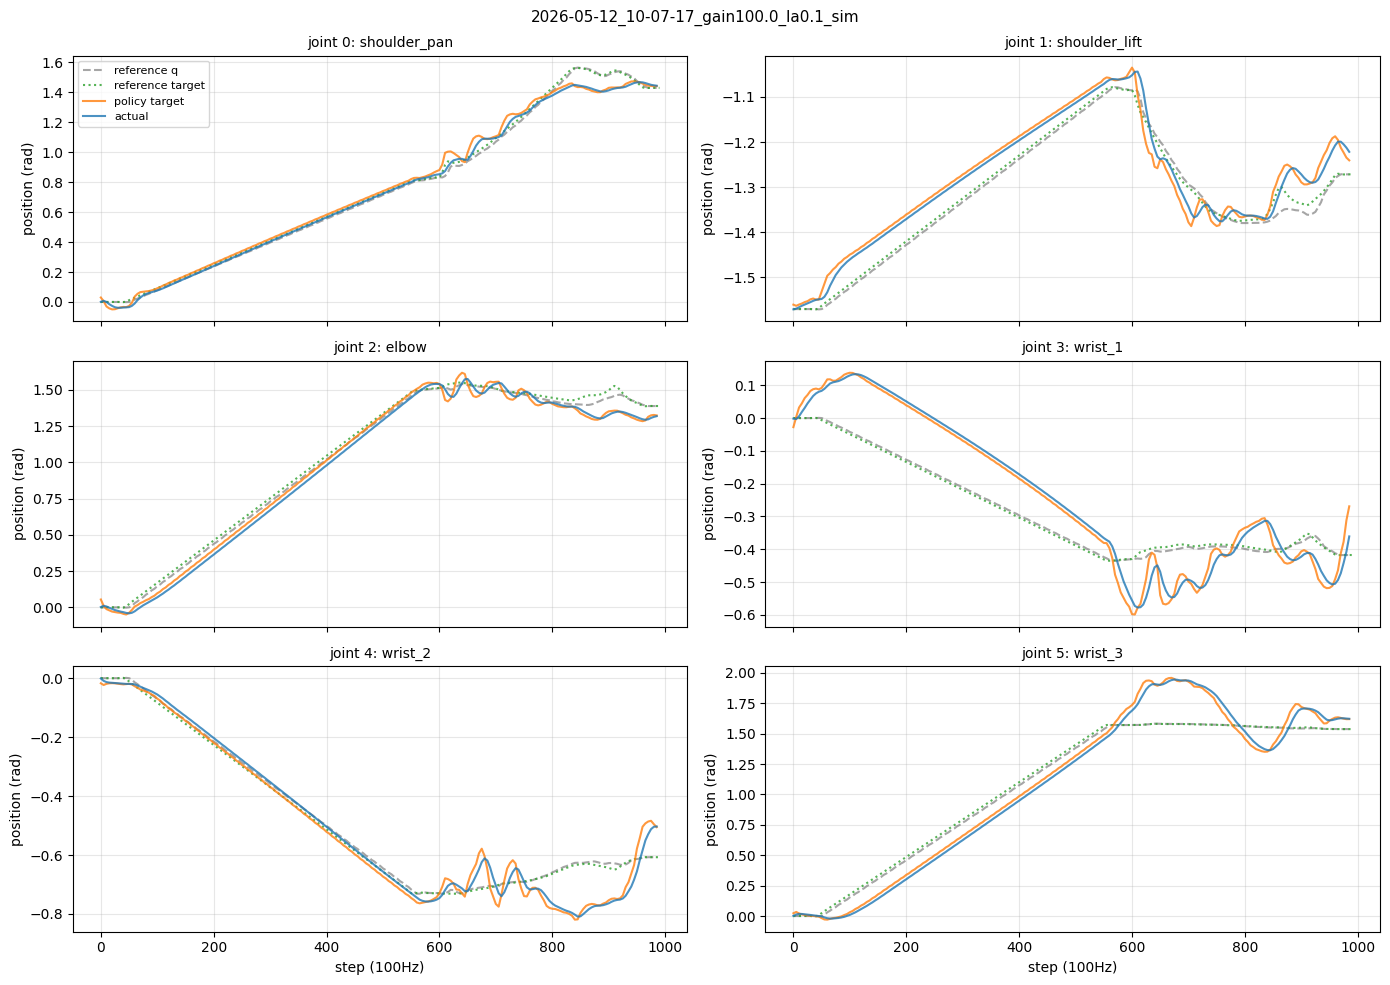

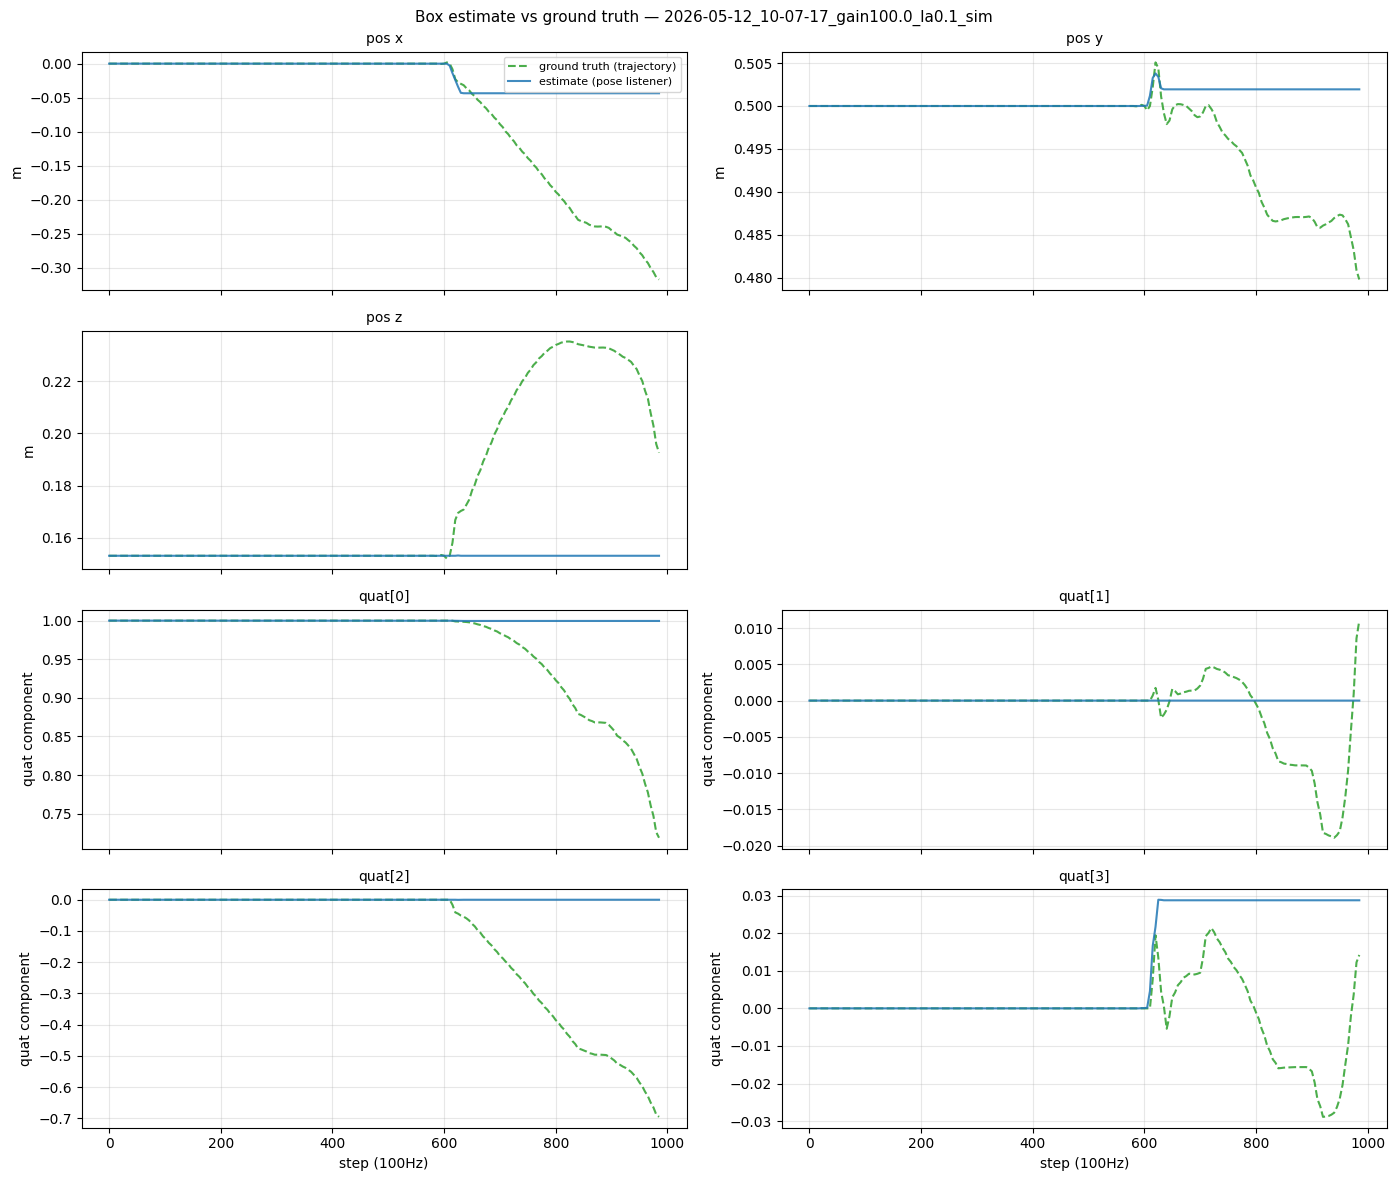

In [70]:
analyze("../logs/rsl_rl/boxhinge/2026-05-12_09-31-09/ur_rtde_logs/2026-05-12_10-07-17_gain100.0_la0.1_sim.npz")

[ 1.45123613 -1.25319493  1.31620407 -0.09878851 -0.50170732  1.57673872]
2026-05-12_09-53-38_gain400.0_la0.06_sim: 4950 rollout steps, 4961 ref steps, rate=500Hz, decimation=10, gain=400.0, lookahead=0.06, action_scale=0.05


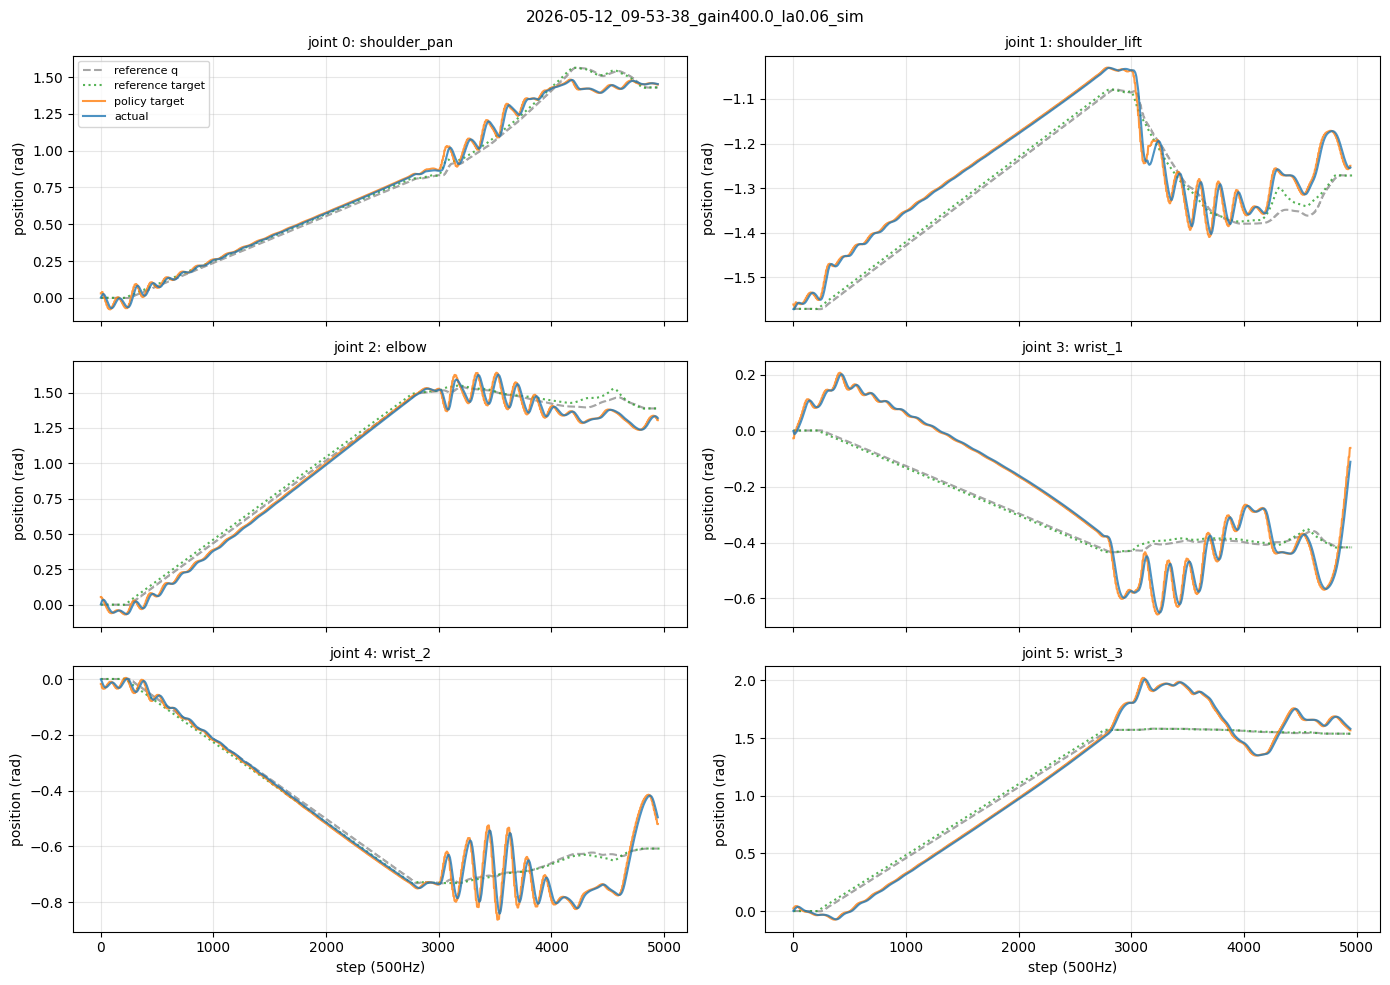

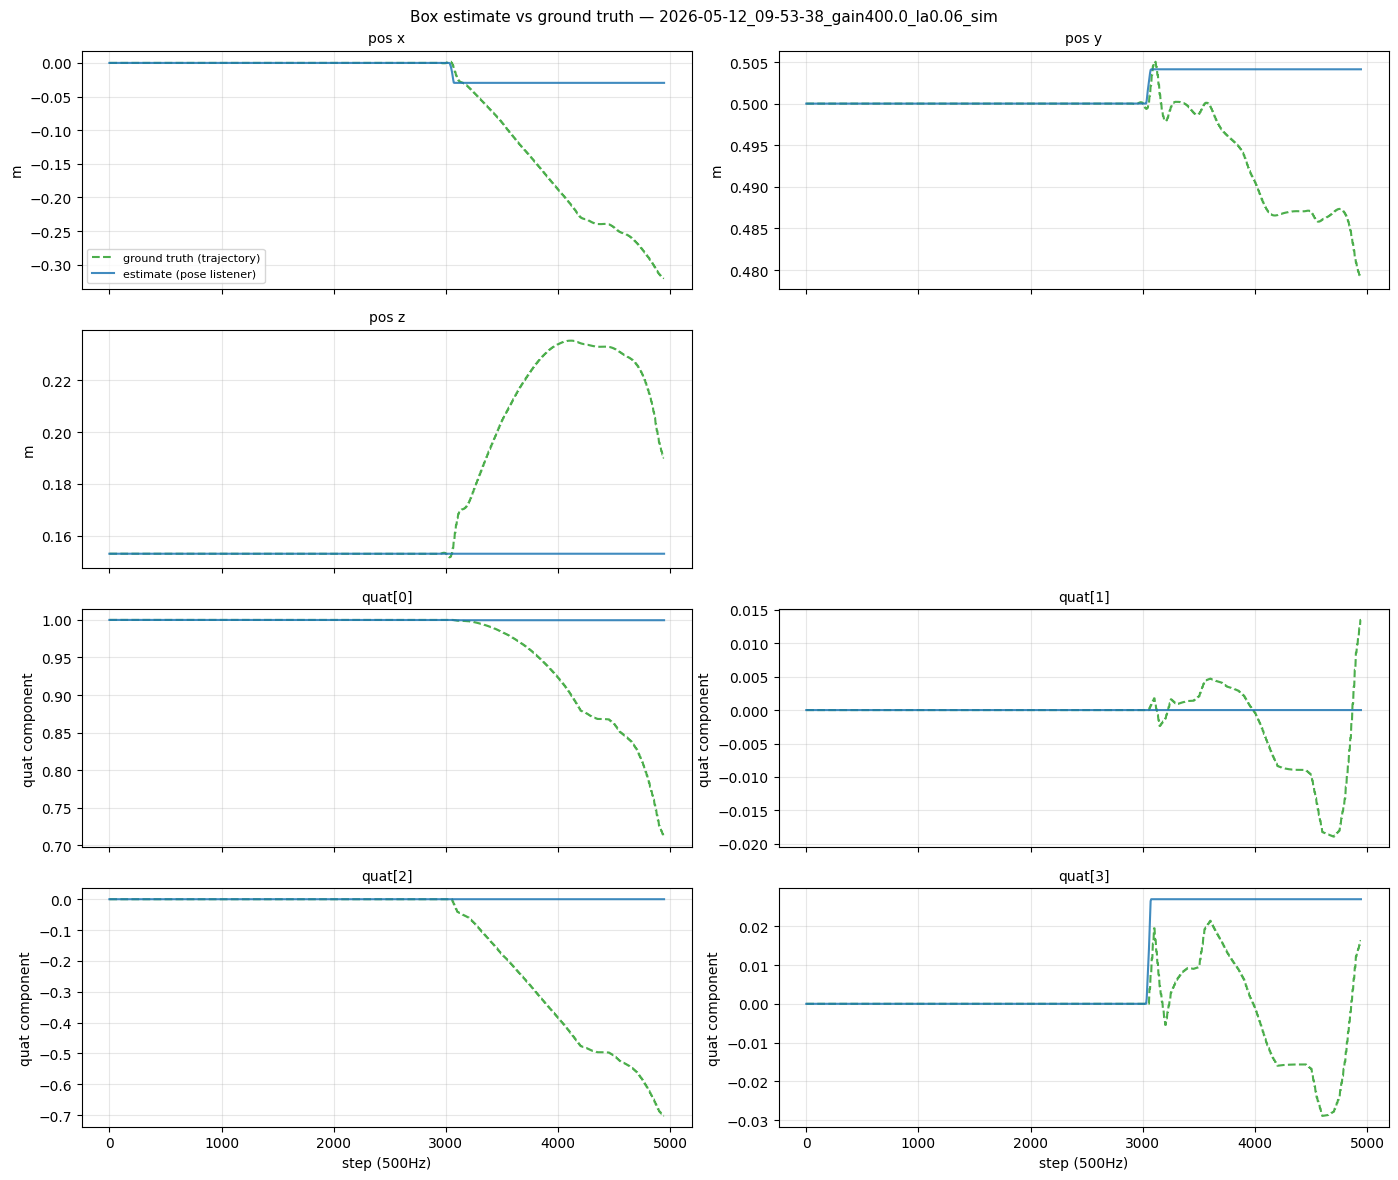

In [71]:
# isaacsim 100hz
analyze("../logs/rsl_rl/boxhinge/2026-05-12_09-31-09/ur_rtde_logs/2026-05-12_09-53-38_gain400.0_la0.06_sim.npz")

[ 1.45123613 -1.25319493  1.31620407 -0.09878851 -0.50170732  1.57673872]
2026-05-12_10-08-39_gain100.0_la0.1_sim: 4950 rollout steps, 4961 ref steps, rate=500Hz, decimation=10, gain=100.0, lookahead=0.1, action_scale=0.05


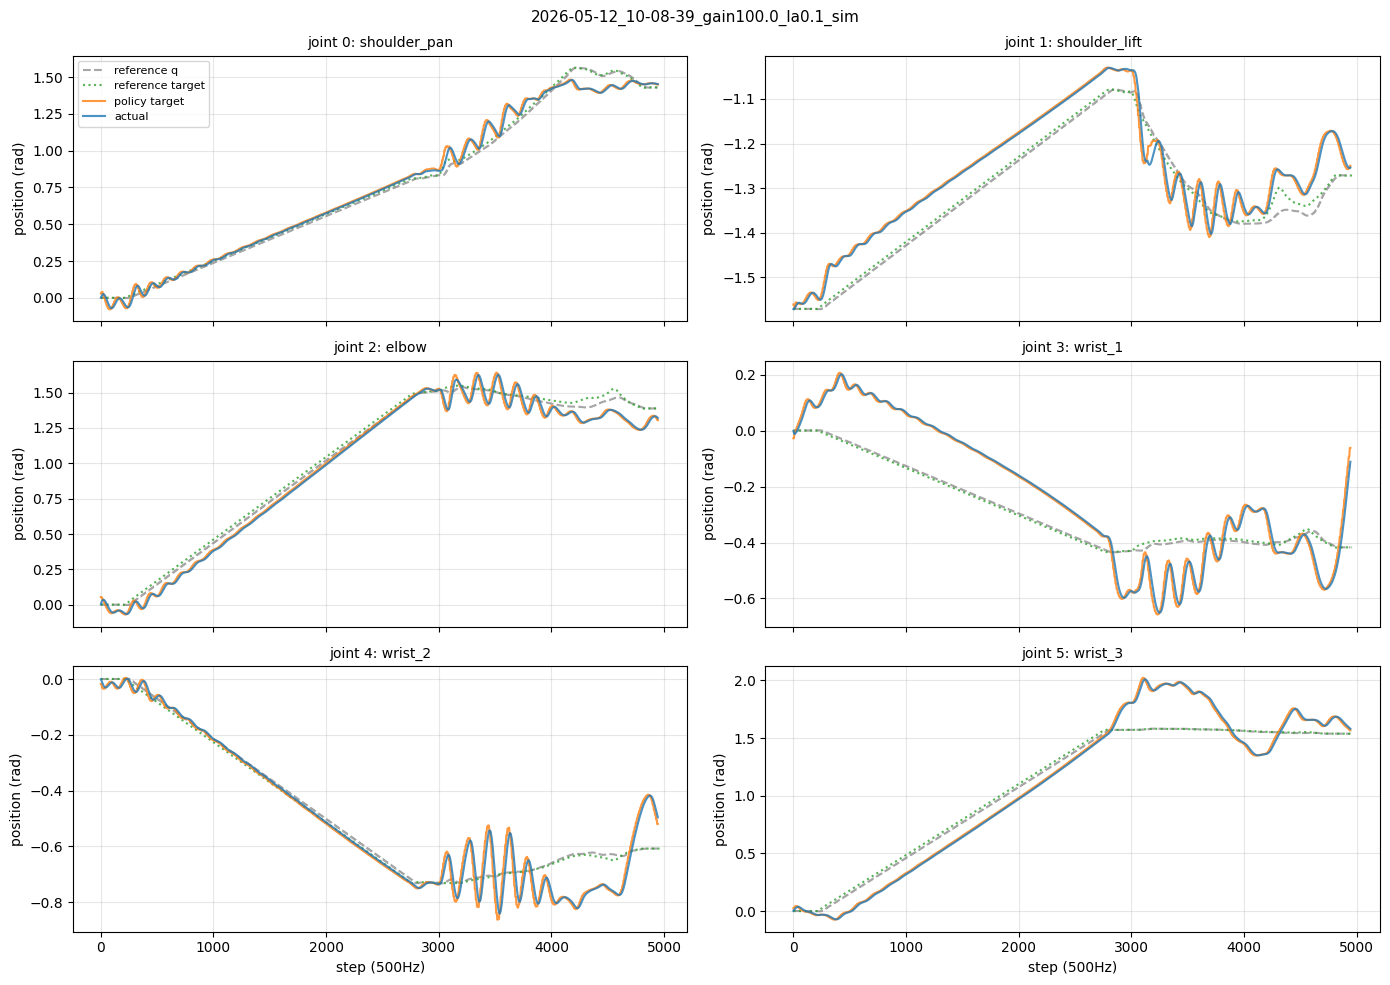

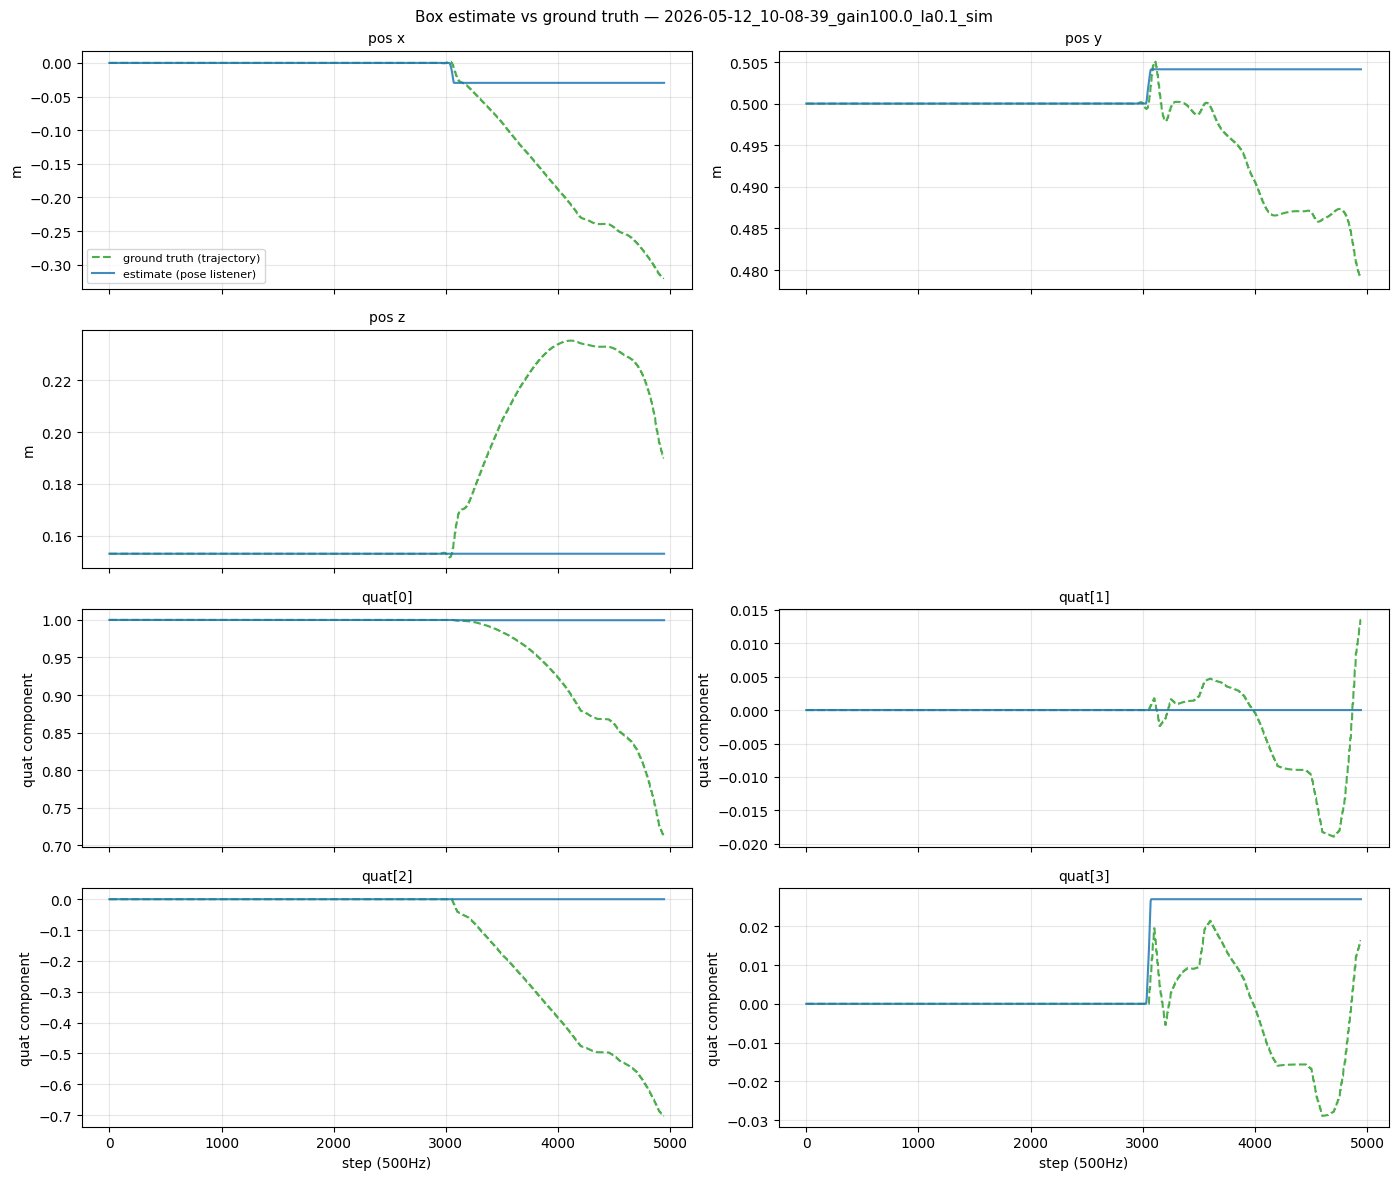

In [72]:
# isaacsim 500hz
analyze("../logs/rsl_rl/boxhinge/2026-05-12_09-31-09/ur_rtde_logs/2026-05-12_10-08-39_gain100.0_la0.1_sim.npz")

[ 1.3085859 -1.4469651  1.4835224 -0.6628259 -0.6669684  1.8425525]
output: 640 rollout steps, 392 ref steps, rate=50Hz, decimation=1, gain=nan, lookahead=nan, action_scale=0.05


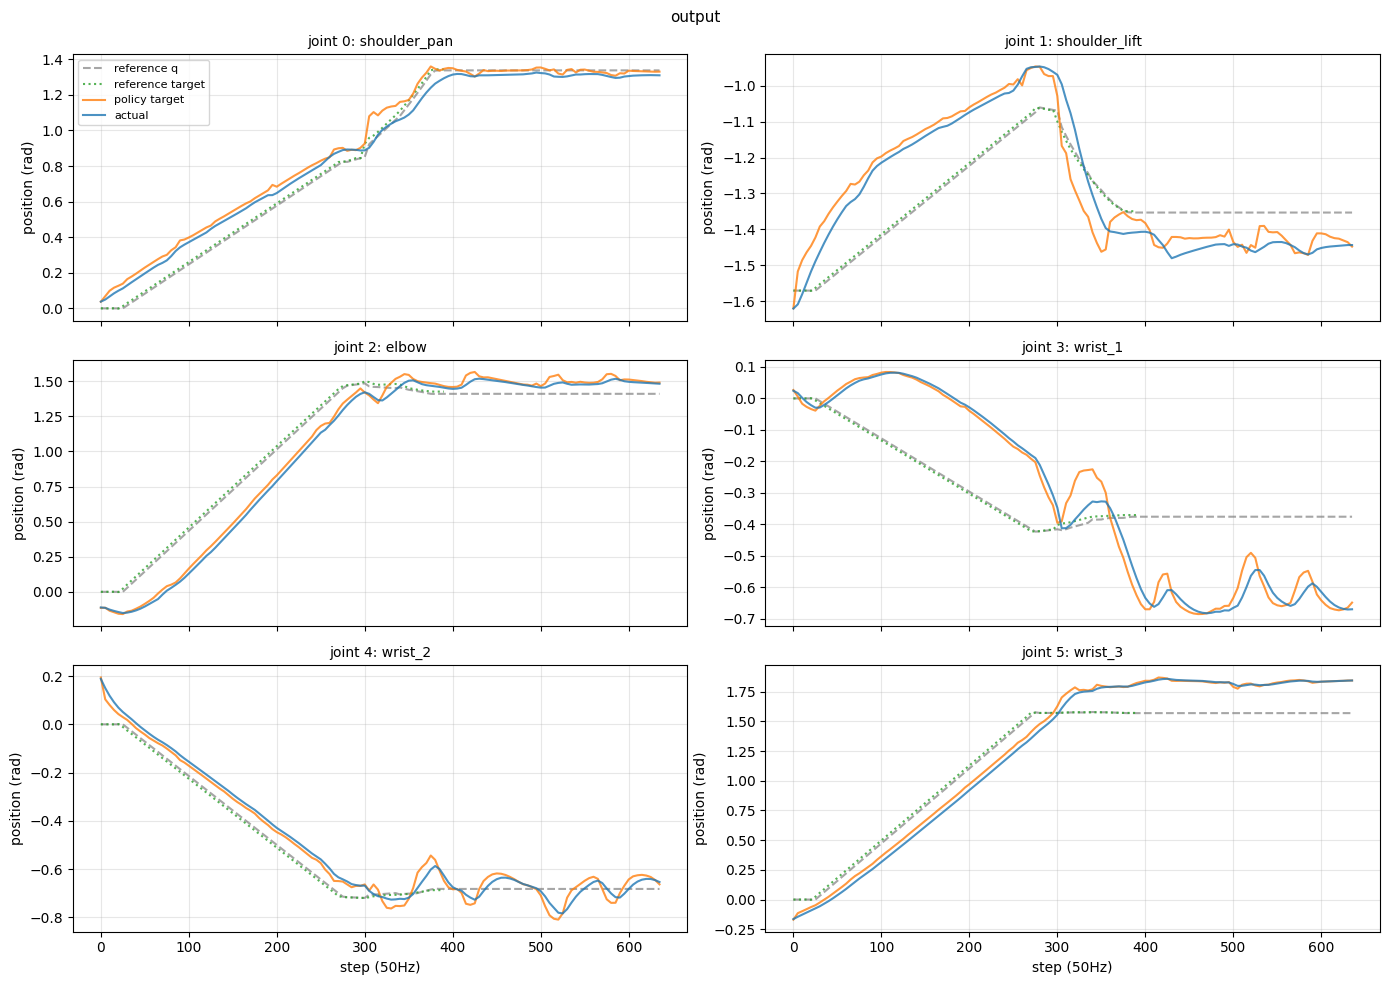

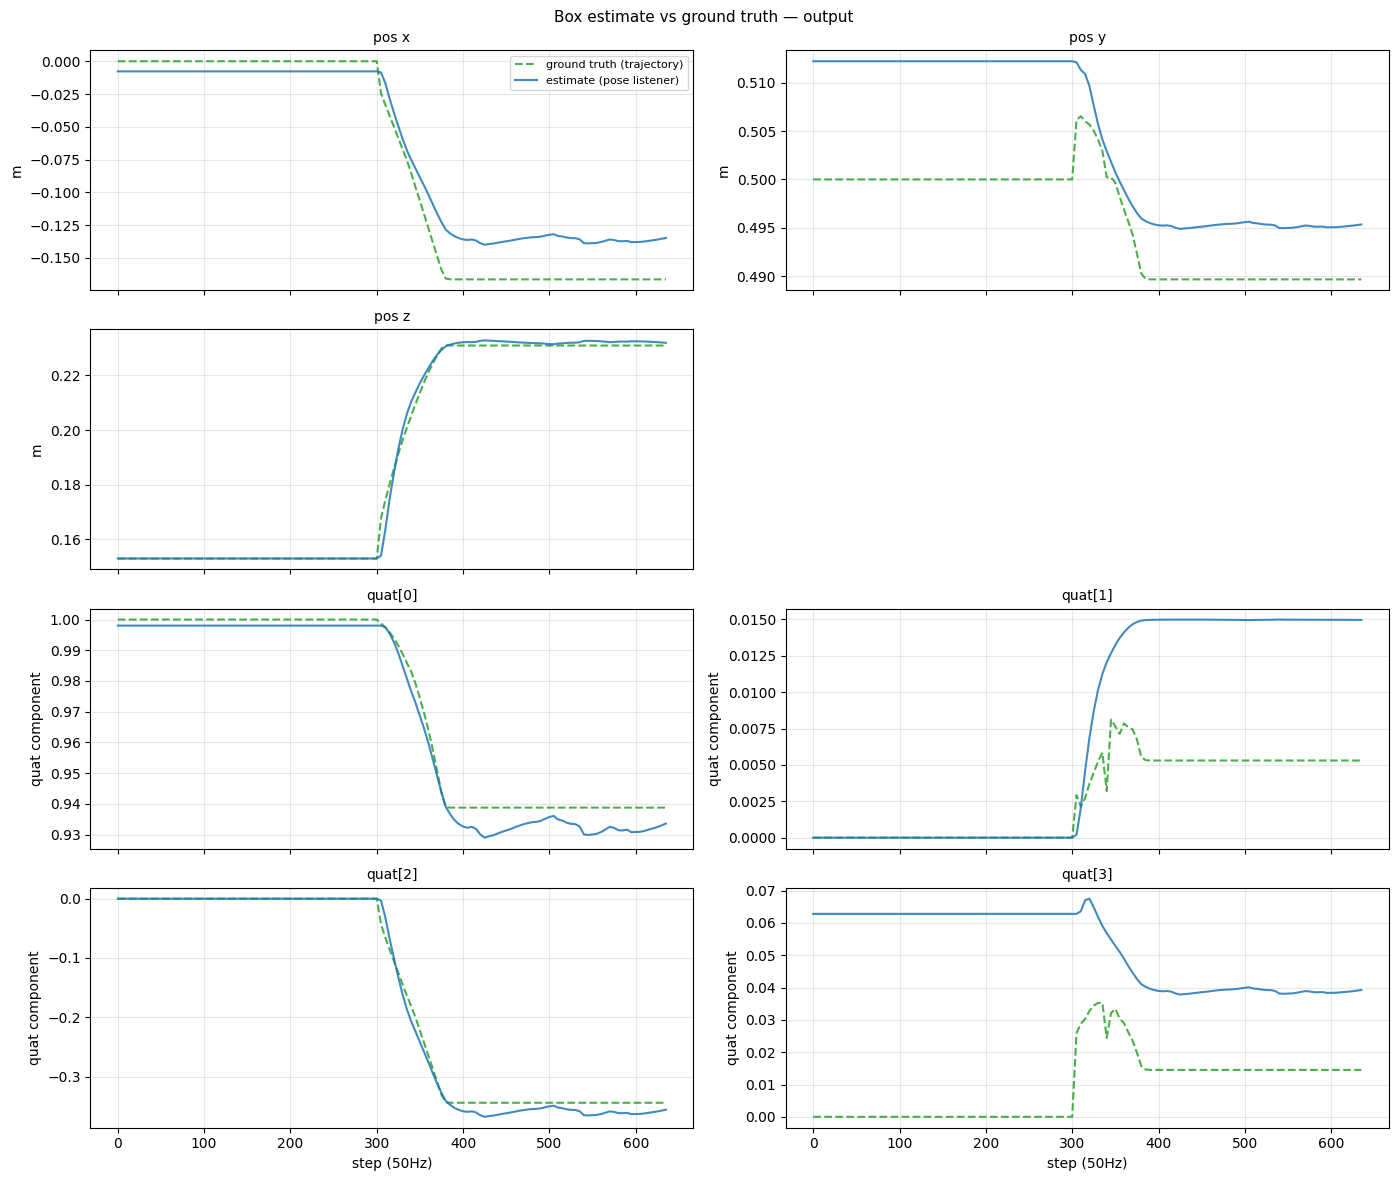

In [75]:
analyze("../logs/rsl_rl/boxhinge/2026-05-14_15-18-14_more_regularization/rollout/output.npz")

[ 1.32273909 -1.37621801  1.48555204 -0.31623161 -0.22703166  1.53951308]
2026-05-14_17-25-59_gain400.0_la0.06_sim: 3902 rollout steps, 3911 ref steps, rate=500Hz, decimation=10, gain=400.0, lookahead=0.06, action_scale=0.05


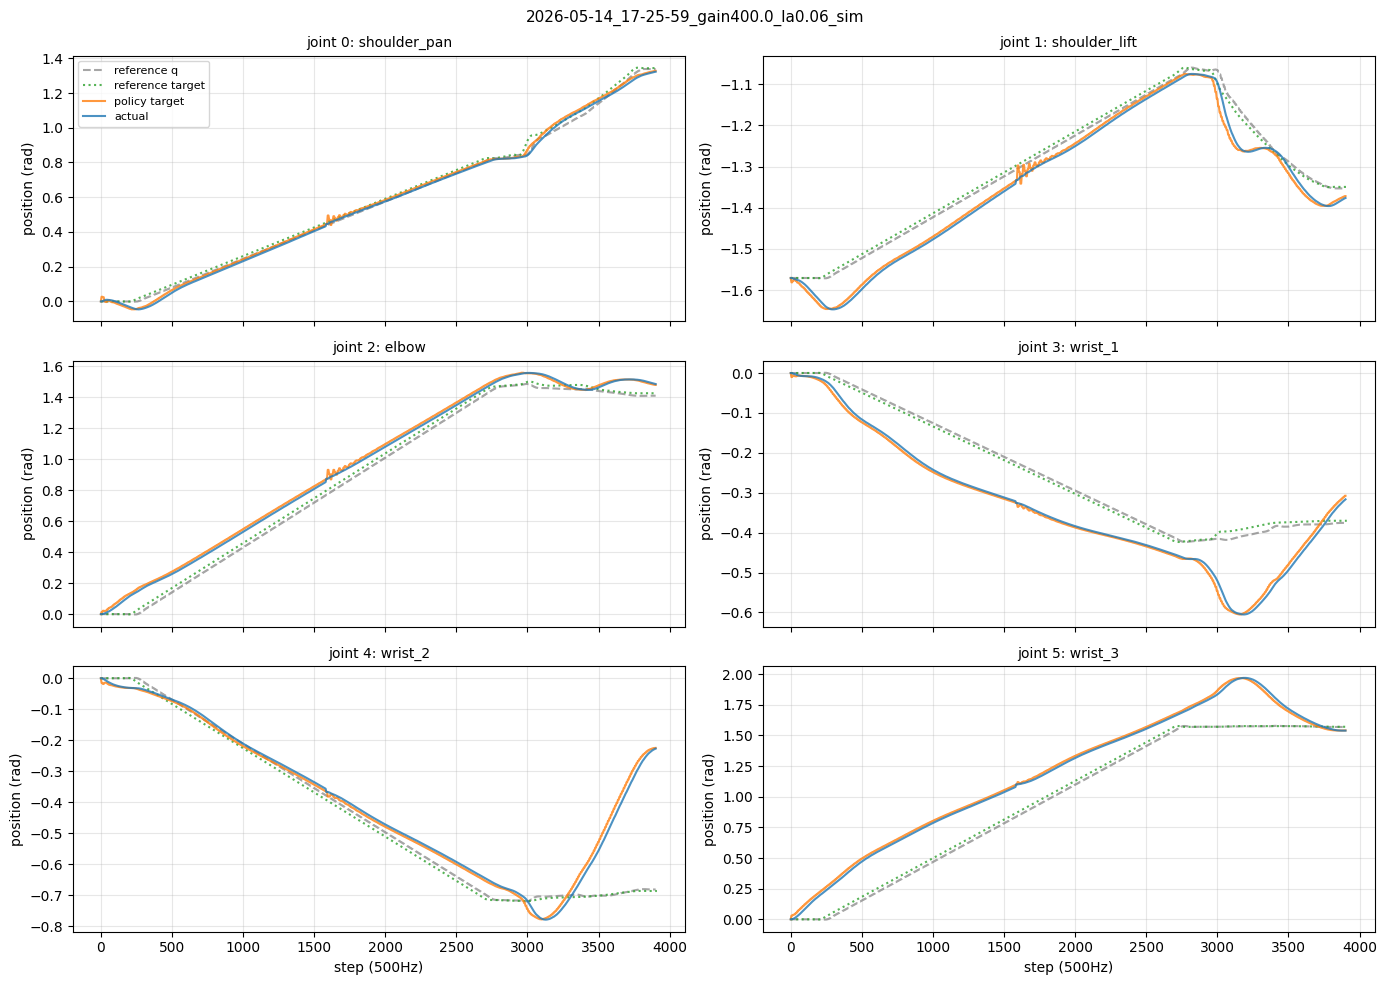

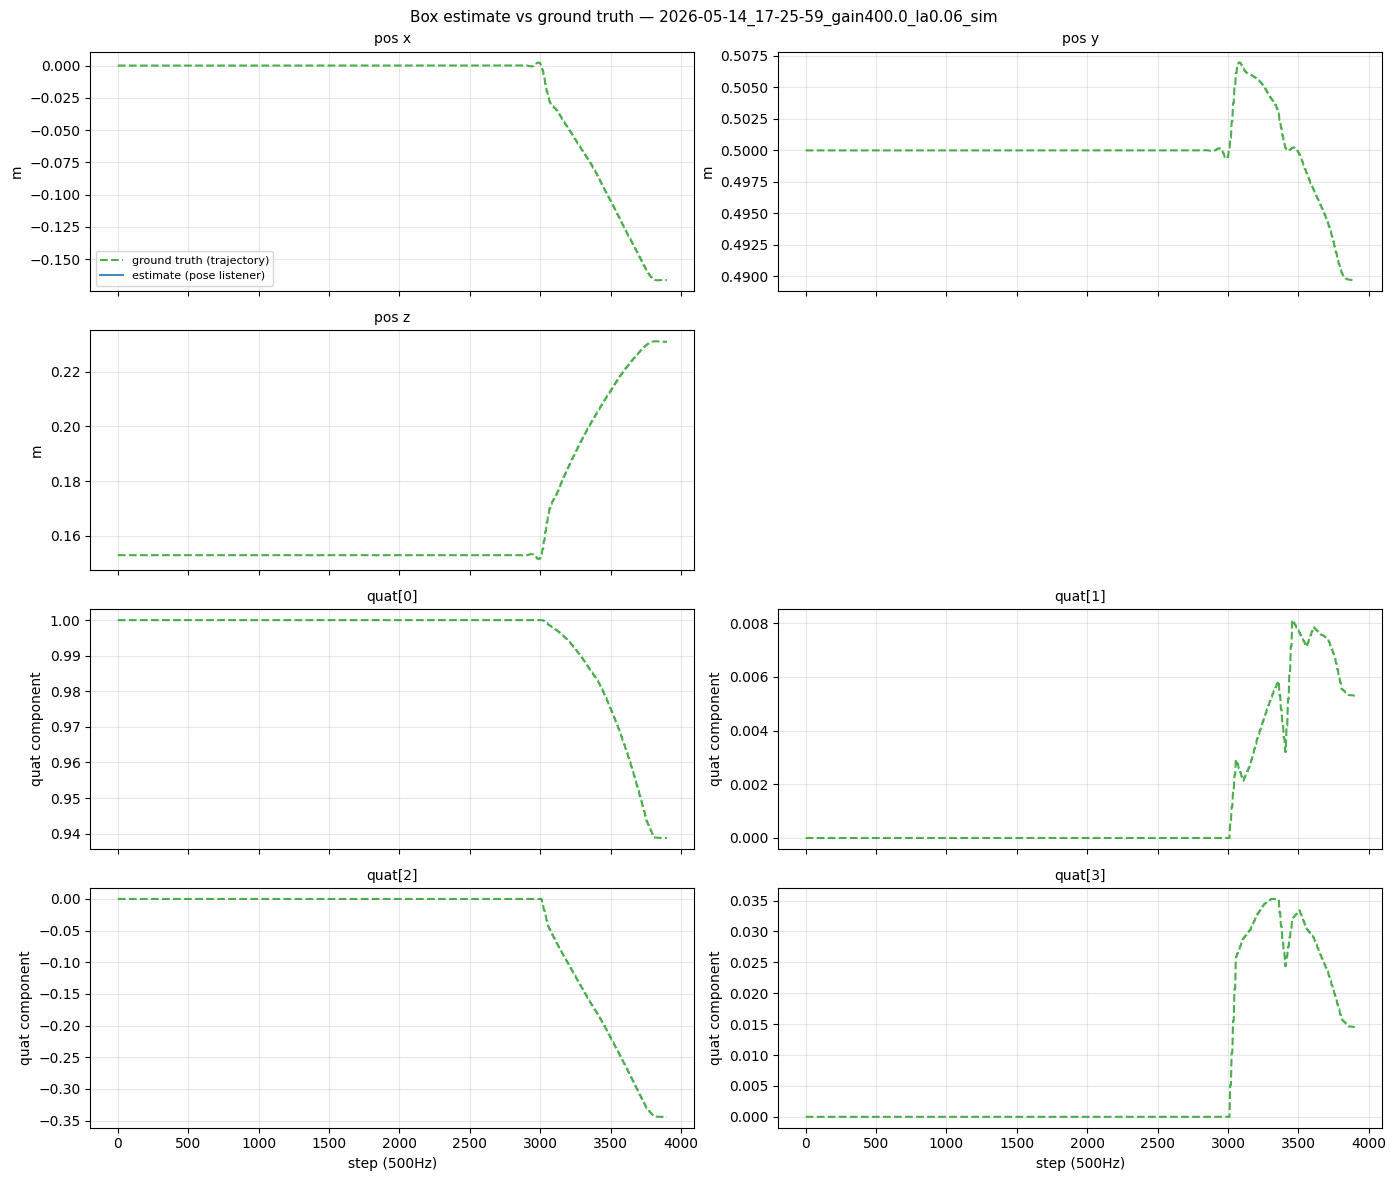

In [77]:
analyze("../logs/rsl_rl/boxhinge/2026-05-14_17-00-16_more_regularization/ur_rtde_logs/2026-05-14_17-25-59_gain400.0_la0.06_sim.npz")

2026-05-13_14-36-32_gain100.0_la0.05_sim: 3902 rollout steps, 3911 ref steps, rate=500Hz, decimation=10, gain=100.0, lookahead=0.05, action_scale=0.05


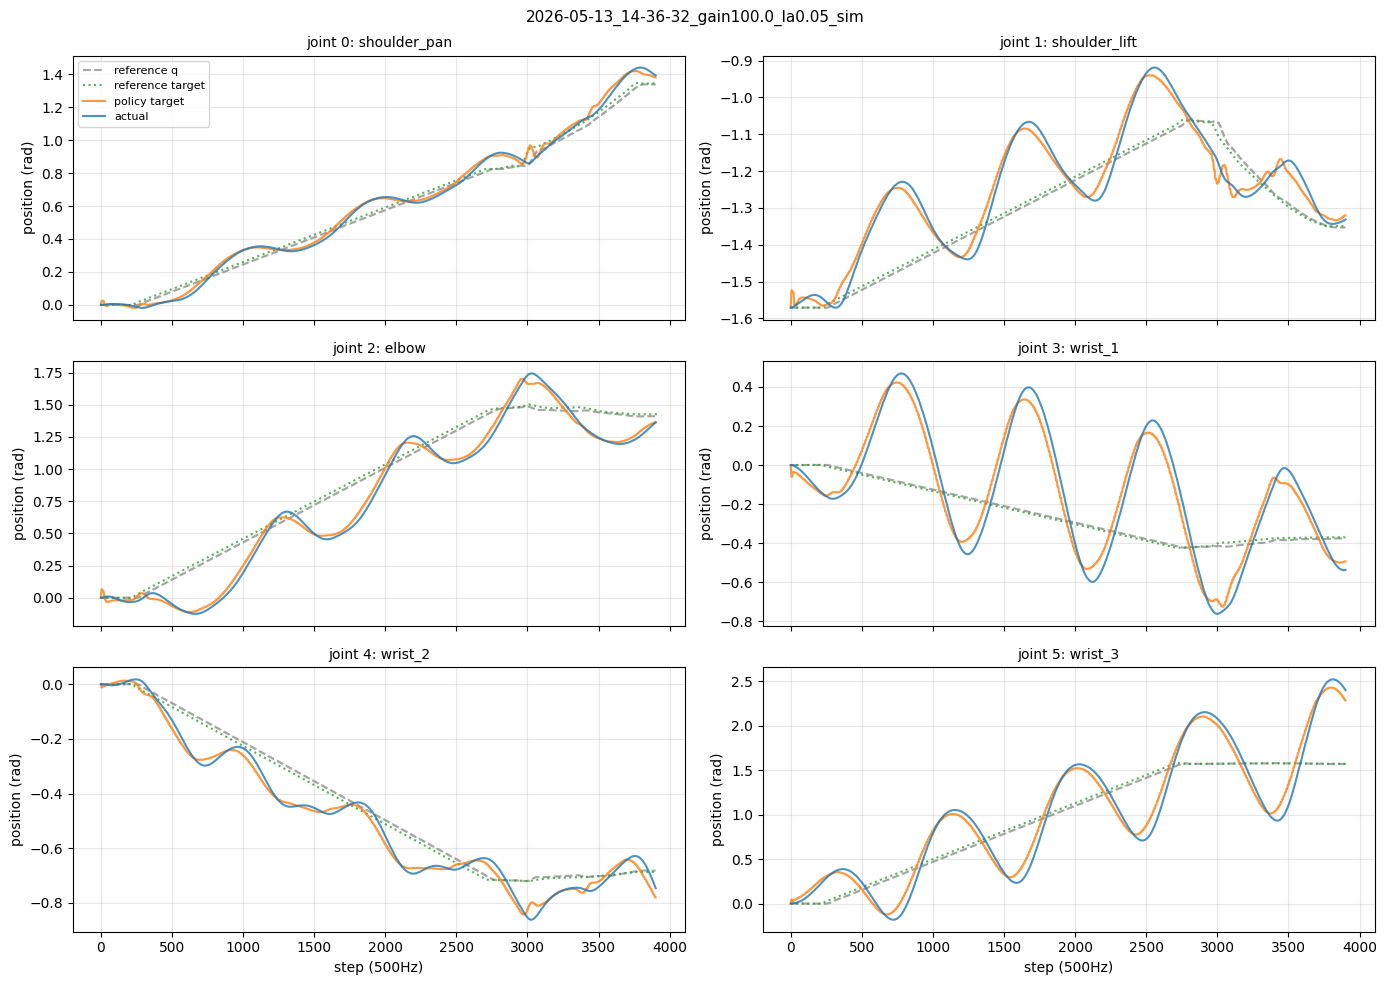

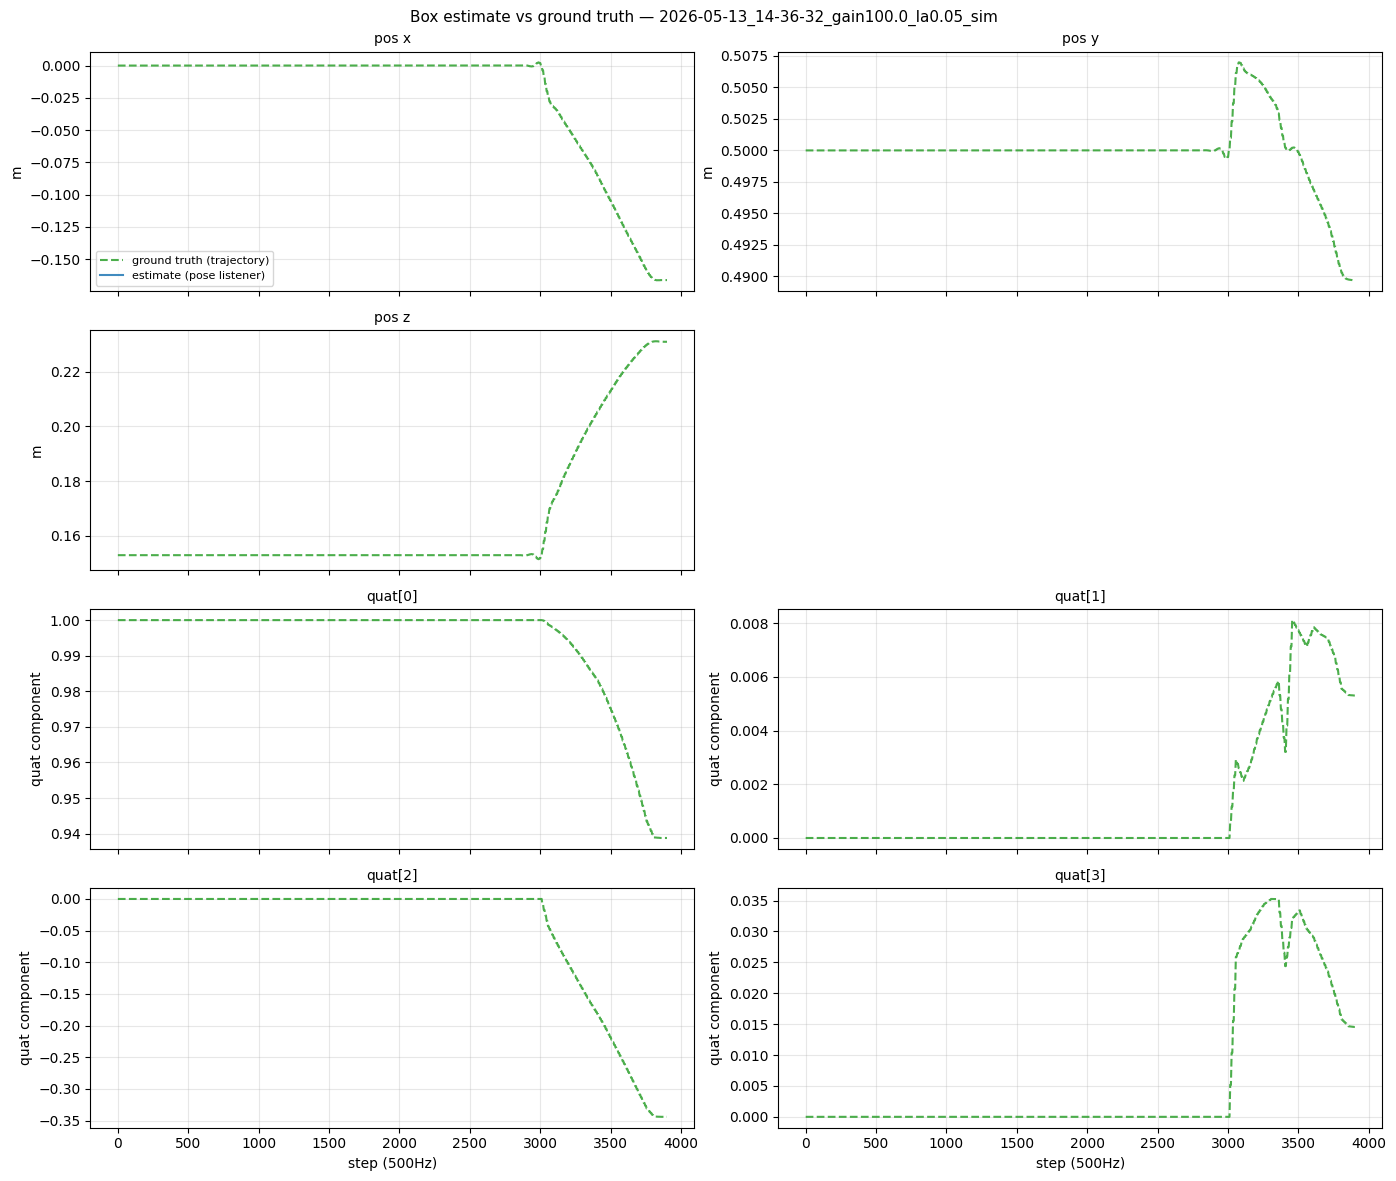

In [44]:
analyze("../logs/rsl_rl/boxhinge/2026-05-12_17-00-36_60_degree_reference_5s_hold_mode_C/ur_rtde_logs/2026-05-13_14-36-32_gain100.0_la0.05_sim.npz")

2026-05-14_15-16-15_gain400.0_la0.06_sim: 3902 rollout steps, 3911 ref steps, rate=500Hz, decimation=10, gain=400.0, lookahead=0.06, action_scale=0.05


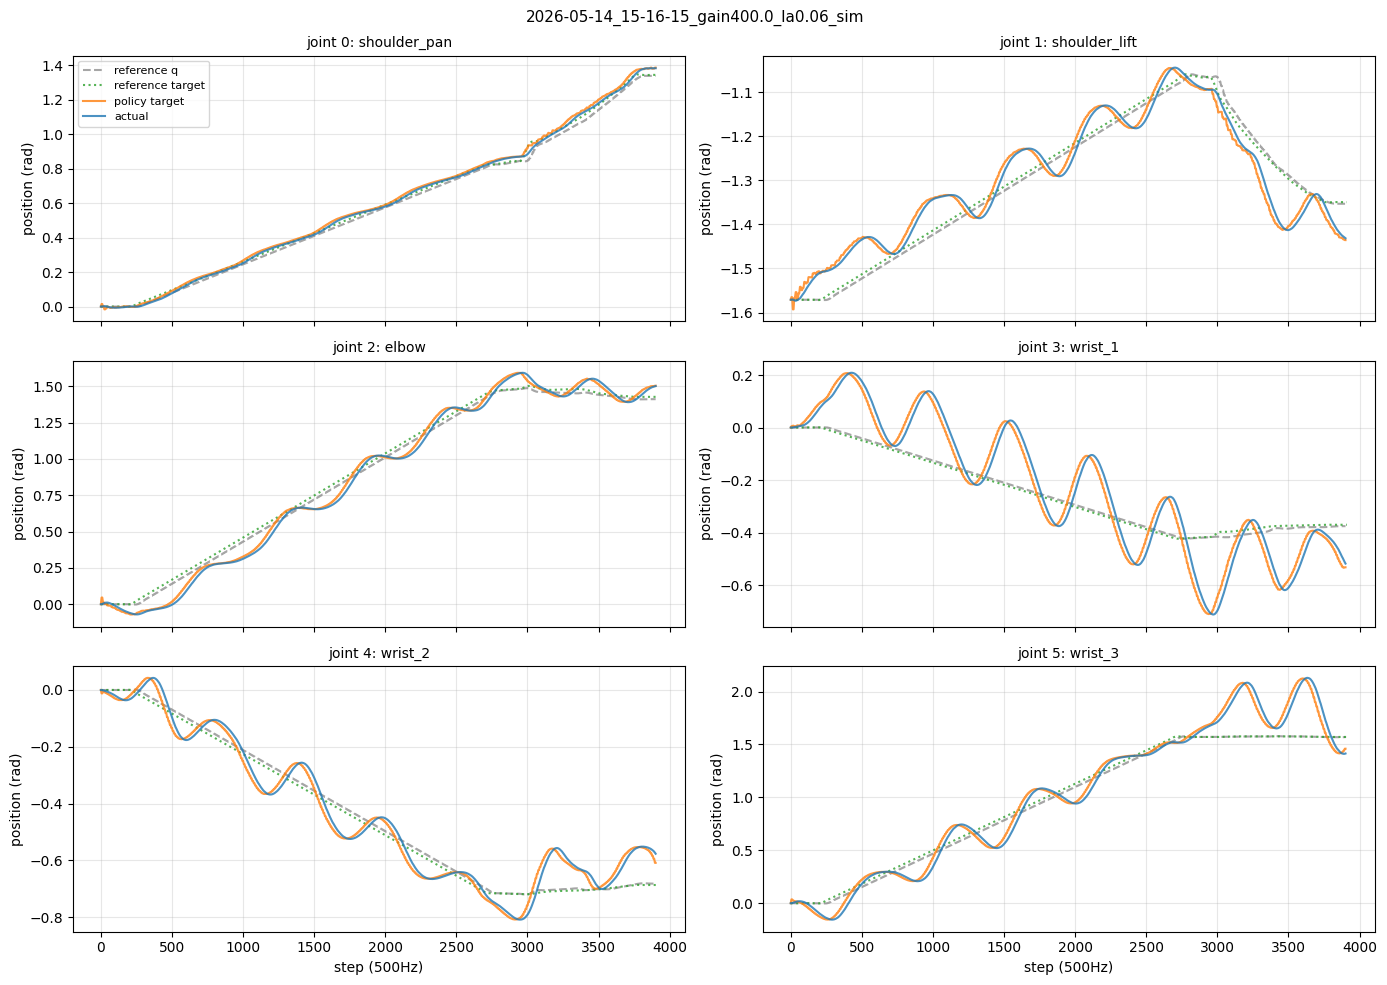

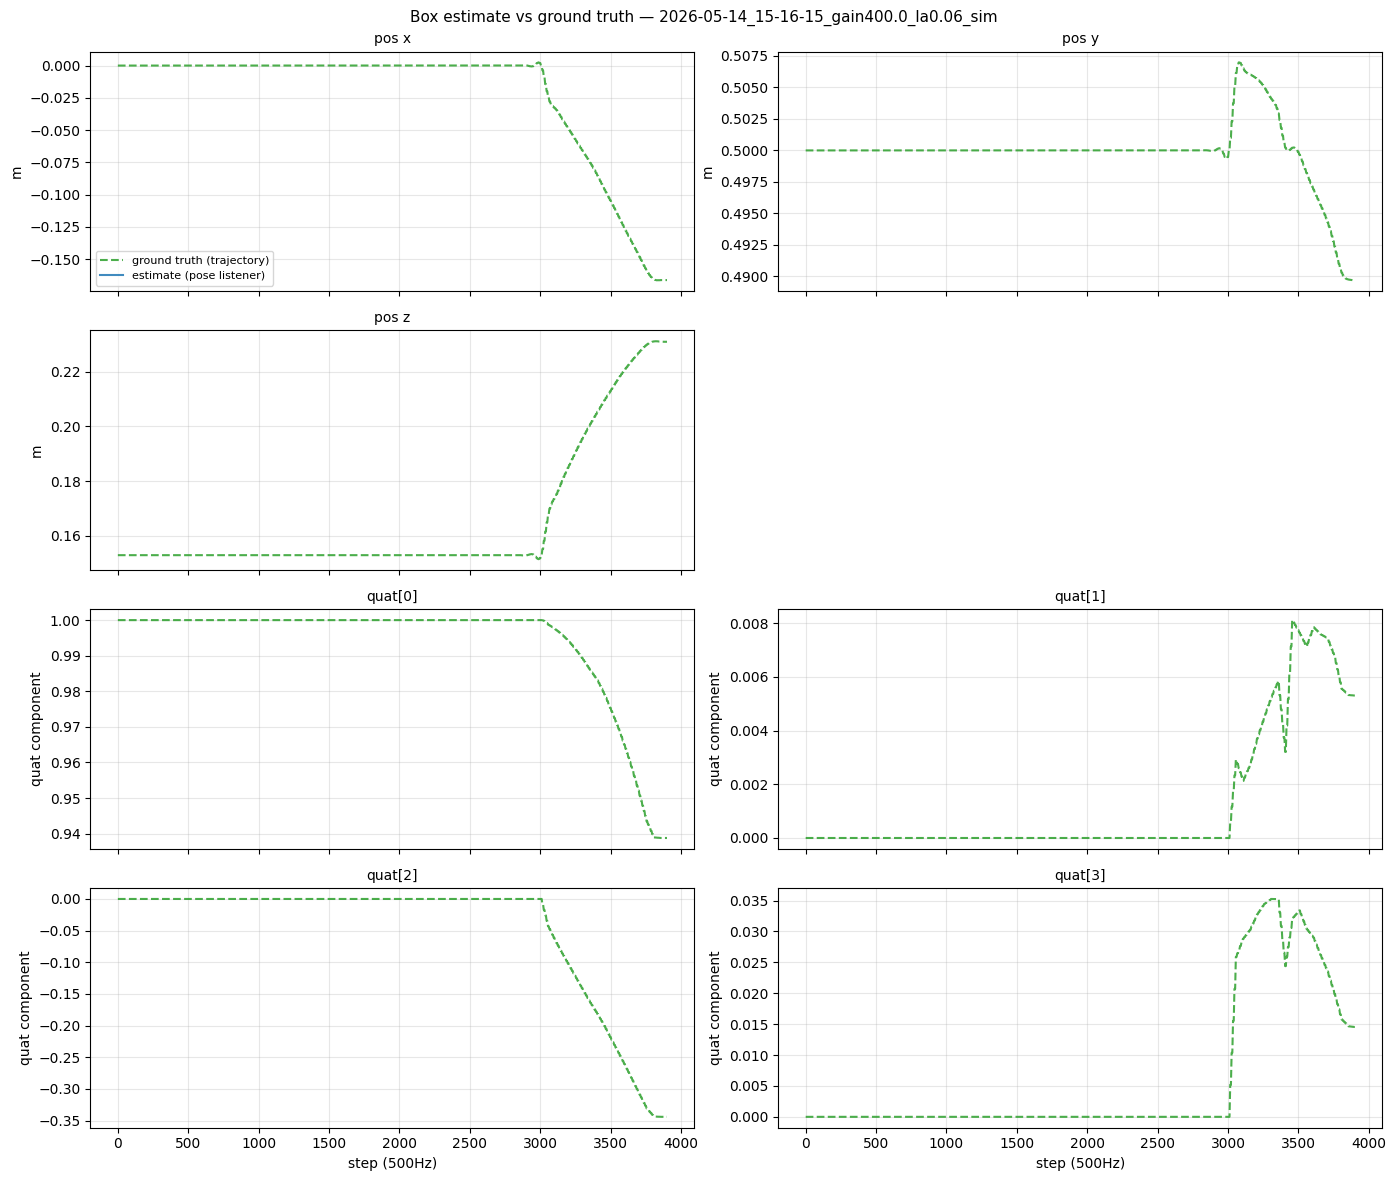

In [45]:
analyze("../logs/rsl_rl/boxhinge/2026-05-14_14-53-38_uniform_time/ur_rtde_logs/2026-05-14_15-16-15_gain400.0_la0.06_sim.npz")